# Eval Results Visualizer

This notebook turns the output from [`results/eval_results.json`](/home/megrad/Documents/GitHub/dont/results/eval_results.json) into a compact evaluation report.

It is designed to work with the current schema produced by [`src/eval.py`](/home/megrad/Documents/GitHub/dont/src/eval.py), including runs where the top-level `benchmark` summary has not been written yet.

The notebook focuses on:

- overall benchmark comparisons across algorithms
- mission-by-mission reward and completion behavior
- safety violation totals and rates
- saliency trends relative to performance


In [20]:
from __future__ import annotations

import json
from collections import defaultdict
from pathlib import Path
from statistics import mean

import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

RESULTS_PATH = Path('../results/eval_results.json')

if not RESULTS_PATH.exists():
    raise FileNotFoundError(f'Could not find results file at {RESULTS_PATH.resolve()}')

data = json.loads(RESULTS_PATH.read_text())
missions = data.get('missions', [])
configured_benchmark = data.get('benchmark') or {}

print(f'Results file: {RESULTS_PATH.resolve()}')
print(f'Missions loaded: {len(missions)}')
print(f'Benchmark present in JSON: {bool(configured_benchmark)}')


Results file: /home/megrad/Documents/GitHub/dont/results/eval_results.json
Missions loaded: 100
Benchmark present in JSON: True


In [21]:
def extract_records(results: dict) -> list[dict]:
    records = []

    for mission in results.get('missions', []):
        mission_index = mission['mission_index']
        for algorithm, metrics in mission.get('algorithms', {}).items():
            mission_stats = metrics.get('mission_stats', [])
            safety = metrics.get('safety_violations', {})
            episode_summary = metrics.get('episode_summary', {})
            reward_totals = ((metrics.get('reward_breakdown') or {}).get('totals') or {})

            wp_reached = sum(drone.get('waypoints_reached', 0) for drone in mission_stats)
            drone_count = max(len(mission_stats), 1)
            avg_dist = sum(drone.get('dist_navigating', 0.0) for drone in mission_stats) / drone_count

            record = {
                'mission_index': mission_index,
                'timestamp': mission.get('timestamp'),
                'algorithm': algorithm,
                'reward': metrics.get('reward', 0.0),
                'steps': metrics.get('steps', 0),
                'saliency_mean': metrics.get('saliency_mean', 0.0),
                'saliency_max': metrics.get('saliency_max', 0.0),
                'duration_s': metrics.get('duration_s', 0.0),
                'reward_per_step': metrics.get('reward_per_step', 0.0),
                'termination_reason': metrics.get('termination_reason', 'unknown'),
                'completed_mission': metrics.get('completed_mission', False),
                'wp_reached': wp_reached,
                'wp_total_est': None,
                'wp_completion_rate': np.nan,
                'avg_dist_m': avg_dist,
                'min_pairwise_distance_m': episode_summary.get('min_pairwise_distance_m', np.nan),
                'caution_count': safety.get('caution', {}).get('total_count', 0),
                'critical_count': safety.get('critical', {}).get('total_count', 0),
                'geofence_count': safety.get('geofence', {}).get('total_count', 0),
                'geofence_outside_steps': safety.get('geofence', {}).get('outside_step_total', 0),
                'hard_safety_count': safety.get('hard_safety', {}).get('total_count', 0),
                'anti_circling_count': safety.get('anti_circling', {}).get('total_count', 0),
                'progress_reward': reward_totals.get('progress_reward', 0.0),
                'best_dist_bonus': reward_totals.get('best_dist_bonus', 0.0),
                'control_effort_penalty': reward_totals.get('control_effort_penalty', 0.0),
                'timestep_penalty': reward_totals.get('timestep_penalty', 0.0),
                'waypoint_hit_reward': reward_totals.get('waypoint_hit_reward', 0.0),
                'geofence_penalty': reward_totals.get('geofence_penalty', 0.0),
                'caution_penalty': reward_totals.get('caution_penalty', 0.0),
                'crash_penalty': reward_totals.get('crash_penalty', 0.0),
                'safety_override_penalty': reward_totals.get('safety_override_penalty', 0.0),
            }
            records.append(record)

    return records


def infer_wp_total(results: dict, records: list[dict]) -> int | None:
    config = (results.get('meta') or {}).get('config') or {}
    drone_cfg = config.get('drone_settings') or {}
    num_drones = drone_cfg.get('num_drones')
    num_wps = drone_cfg.get('num_wps_per_drone')
    if num_drones and num_wps:
        return num_drones * num_wps
    totals = [record['wp_reached'] for record in records if record['wp_reached']]
    return max(set(totals), key=totals.count) if totals else None


def summarize(records: list[dict]) -> dict[str, dict]:
    grouped = defaultdict(list)
    for record in records:
        grouped[record['algorithm']].append(record)

    summary = {}
    for algorithm, rows in grouped.items():
        finite_min_sep = [row['min_pairwise_distance_m'] for row in rows if np.isfinite(row['min_pairwise_distance_m'])]
        summary[algorithm] = {
            'mean_reward': mean(row['reward'] for row in rows),
            'std_reward': float(np.std([row['reward'] for row in rows])),
            'avg_steps': mean(row['steps'] for row in rows),
            'avg_duration_s': mean(row['duration_s'] for row in rows),
            'avg_dist_m': mean(row['avg_dist_m'] for row in rows),
            'avg_reward_per_step': mean(row['reward_per_step'] for row in rows),
            'wp_completion_rate': mean(row['wp_completion_rate'] for row in rows),
            'mission_completion_rate': mean(1 if row['completed_mission'] else 0 for row in rows),
            'crash_rate': mean(1 if row['critical_count'] > 0 else 0 for row in rows),
            'avg_caution': mean(row['caution_count'] for row in rows),
            'avg_geofence': mean(row['geofence_count'] for row in rows),
            'avg_geofence_outside_steps': mean(row['geofence_outside_steps'] for row in rows),
            'avg_min_pairwise_distance_m': float(np.mean(finite_min_sep)) if finite_min_sep else np.nan,
            'avg_saliency': mean(row['saliency_mean'] for row in rows),
            'num_missions': len(rows),
        }
    return summary


records = extract_records(data)
if not records:
    raise ValueError('No mission records were found in the eval results file.')

wp_total = infer_wp_total(data, records)
if wp_total:
    for record in records:
        record['wp_total_est'] = wp_total
        record['wp_completion_rate'] = record['wp_reached'] / wp_total if wp_total else 0.0

summary = summarize(records)
algorithms = sorted(summary.keys())
colors = {
    'A2C': '#1f77b4',
    'PPO': '#2ca02c',
    'SAC': '#d62728',
}

if pd is not None:
    records_df = pd.DataFrame(records)
    summary_df = pd.DataFrame(summary).T.sort_values('mean_reward', ascending=False)
else:
    records_df = None
    summary_df = None


## Run Summary

This first section gives a quick read on the evaluation run itself: how many missions were captured, which algorithms are present, and the derived benchmark table used by the rest of the notebook.

If the JSON already contains a top-level `benchmark` section, you can compare it against the derived values here. If not, this notebook computes the same style of summary directly from the mission records.

In [22]:
config = (data.get('meta') or {}).get('config') or {}

print('Algorithms:', ', '.join(algorithms))
print('Configured missions:', (config.get('eval') or {}).get('num_missions', 'unknown'))
print('Observed missions:', len(missions))
print('Drones per mission:', (config.get('drone_settings') or {}).get('num_drones', 'unknown'))
print('Waypoints per drone:', (config.get('drone_settings') or {}).get('num_wps_per_drone', 'unknown'))
print('Estimated total waypoints per mission:', wp_total if wp_total is not None else 'unknown')

if summary_df is not None:
    display(summary_df.round(4))
else:
    for algorithm in sorted(summary, key=lambda name: summary[name]['mean_reward'], reverse=True):
        print(f'\n[{algorithm}]')
        for key, value in summary[algorithm].items():
            print(f'  {key}: {value:.4f}' if isinstance(value, float) else f'  {key}: {value}')


Algorithms: A2C, PPO
Configured missions: 100
Observed missions: 100
Drones per mission: 2
Waypoints per drone: 20
Estimated total waypoints per mission: 40


,mean_reward,std_reward,avg_steps,avg_duration_s,avg_dist_m,avg_reward_per_step,wp_completion_rate,mission_completion_rate,crash_rate,avg_caution,avg_geofence,avg_geofence_outside_steps,avg_min_pairwise_distance_m,avg_saliency,num_missions
PPO,223197.8292,97415.4561,2089.97,626.991,13233.3148,129.2421,0.9080,0.79,0.19,15.63,0.51,18.48,28.0774,0.0002,100.0
A2C,191761.7202,156782.3427,2150.70,645.210,12422.1916,156.7680,0.8572,0.64,0.28,11.63,0.04,1.48,35.8785,0.0002,100.0


## Benchmark Comparison

These charts answer the top-level question: which policy is strongest overall, and how does that strength trade off against efficiency and mission completion?

Use the four panels together:

- `Mean Reward`: overall objective quality
- `Reward Std Dev`: stability across missions
- `Average Steps`: efficiency to finish or fail
- `Waypoint Completion Rate`: how fully each policy completes the mission

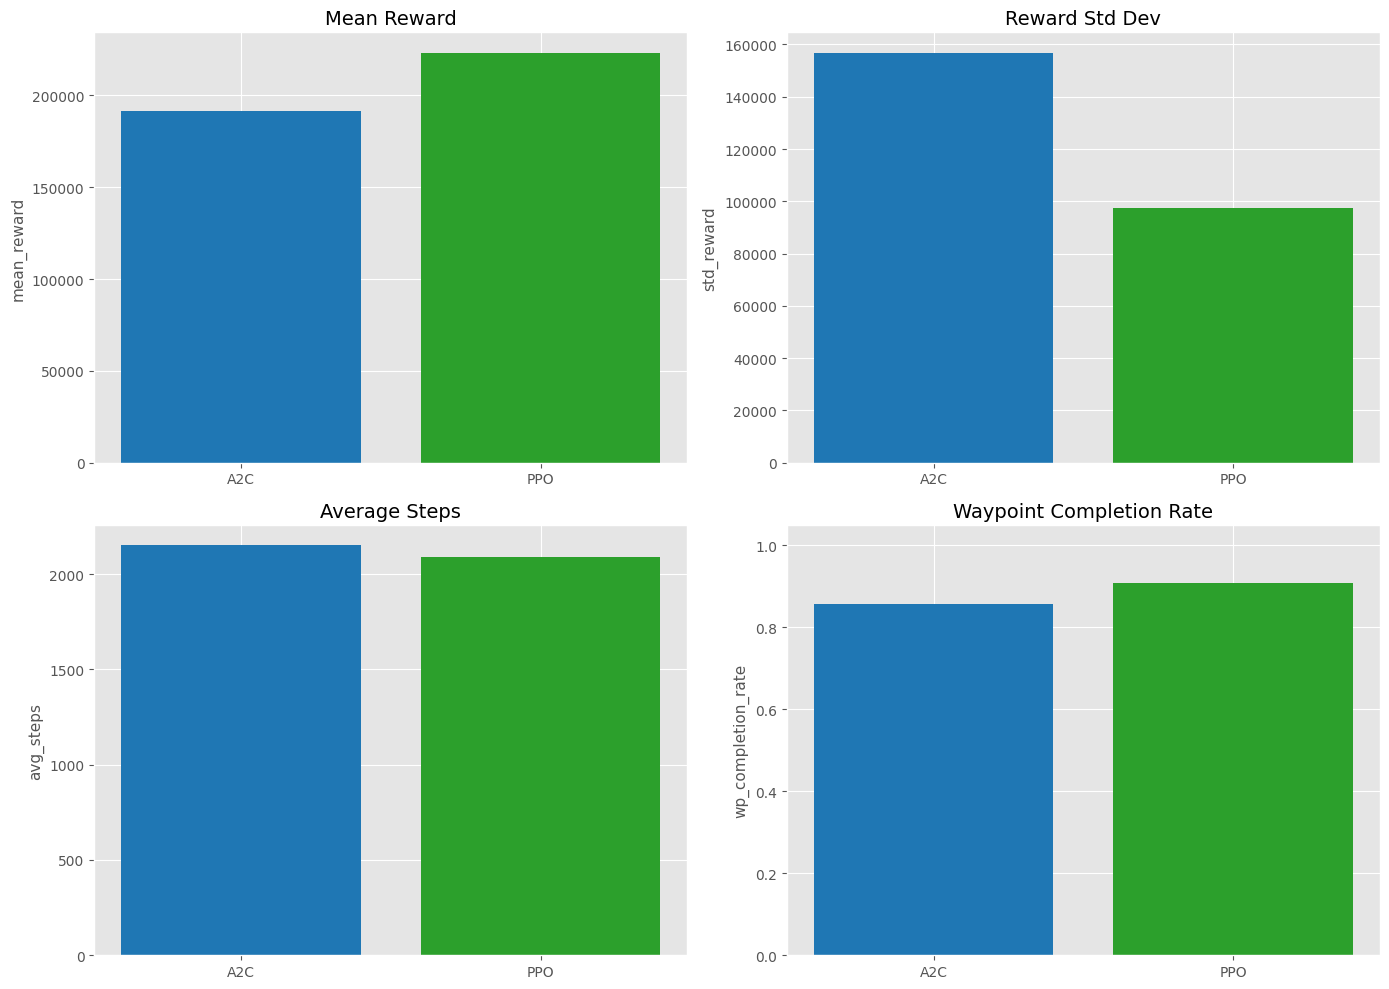

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [
    ('mean_reward', 'Mean Reward'),
    ('std_reward', 'Reward Std Dev'),
    ('avg_steps', 'Average Steps'),
    ('wp_completion_rate', 'Waypoint Completion Rate'),
]

for ax, (metric_key, title) in zip(axes.flat, metrics):
    values = [summary[algorithm][metric_key] for algorithm in algorithms]
    ax.bar(algorithms, values, color=[colors.get(algorithm, '#444444') for algorithm in algorithms])
    ax.set_title(title)
    if metric_key == 'wp_completion_rate':
        ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric_key)

plt.tight_layout()
plt.show()


## Reward Behavior Across Missions

A high mean reward can still hide instability. The next views show whether performance is concentrated in a few missions or consistently strong over the whole run.

The boxplot emphasizes spread and outliers, while the line chart reveals mission ordering effects such as sudden collapses or steady dominance.

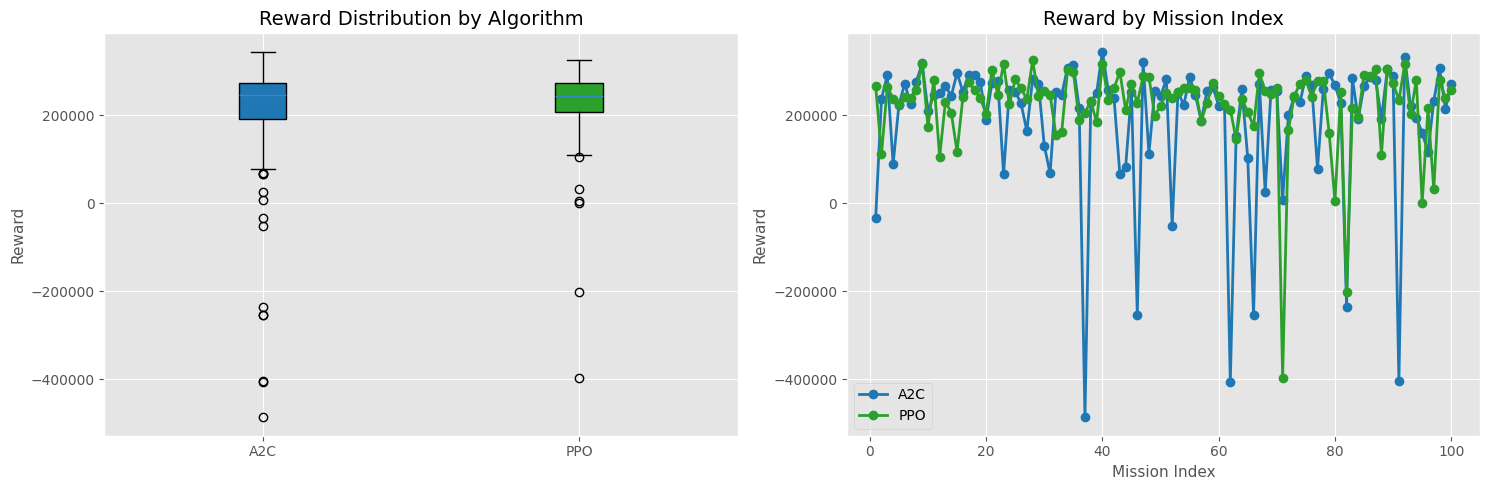

In [24]:
grouped_rewards = [
    [record['reward'] for record in records if record['algorithm'] == algorithm]
    for algorithm in algorithms
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bp = axes[0].boxplot(grouped_rewards, tick_labels=algorithms, patch_artist=True)
for patch, algorithm in zip(bp['boxes'], algorithms):
    patch.set_facecolor(colors.get(algorithm, '#999999'))
axes[0].set_title('Reward Distribution by Algorithm')
axes[0].set_ylabel('Reward')

for algorithm in algorithms:
    algo_records = sorted(
        (record for record in records if record['algorithm'] == algorithm),
        key=lambda row: row['mission_index']
    )
    axes[1].plot(
        [row['mission_index'] for row in algo_records],
        [row['reward'] for row in algo_records],
        marker='o',
        linewidth=2,
        label=algorithm,
        color=colors.get(algorithm, '#444444')
    )

axes[1].set_title('Reward by Mission Index')
axes[1].set_xlabel('Mission Index')
axes[1].set_ylabel('Reward')
axes[1].legend()

plt.tight_layout()
plt.show()


## Completion And Distance

Completion rate tells us how much of the mission is actually being finished, while average distance traveled per drone helps separate efficient mission execution from policies that simply survive for a long time.

A strong policy should generally pair high completion with comparatively low average navigation distance.

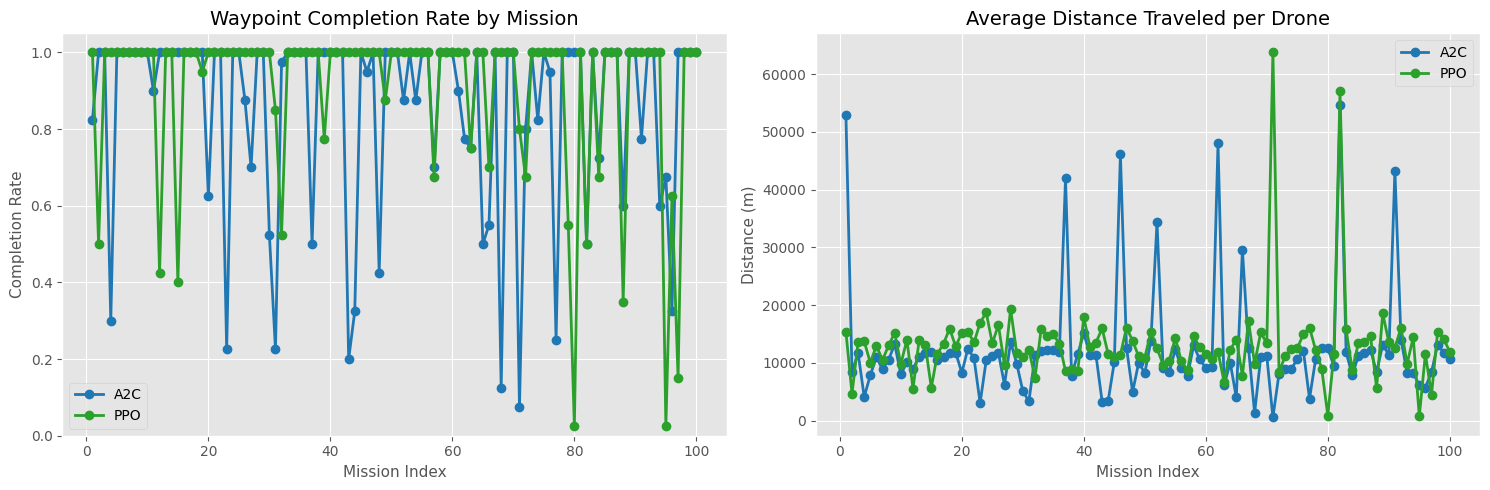

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for algorithm in algorithms:
    algo_records = sorted(
        (record for record in records if record['algorithm'] == algorithm),
        key=lambda row: row['mission_index']
    )
    mission_idx = [row['mission_index'] for row in algo_records]
    completion = [row['wp_completion_rate'] for row in algo_records]
    avg_dist = [row['avg_dist_m'] for row in algo_records]

    axes[0].plot(mission_idx, completion, marker='o', linewidth=2, label=algorithm, color=colors.get(algorithm, '#444444'))
    axes[1].plot(mission_idx, avg_dist, marker='o', linewidth=2, label=algorithm, color=colors.get(algorithm, '#444444'))

axes[0].set_title('Waypoint Completion Rate by Mission')
axes[0].set_xlabel('Mission Index')
axes[0].set_ylabel('Completion Rate')
axes[0].set_ylim(0, 1.05)
axes[0].legend()

axes[1].set_title('Average Distance Traveled per Drone')
axes[1].set_xlabel('Mission Index')
axes[1].set_ylabel('Distance (m)')
axes[1].legend()

plt.tight_layout()
plt.show()


## Safety Profile

This section breaks safety into separate failure modes instead of folding everything into reward.

The stacked totals show how the absolute burden is distributed across caution, critical, geofence, hard-safety, and anti-circling events. The crash-rate panel turns critical violations into a mission-level rate, which is often easier to compare across runs.

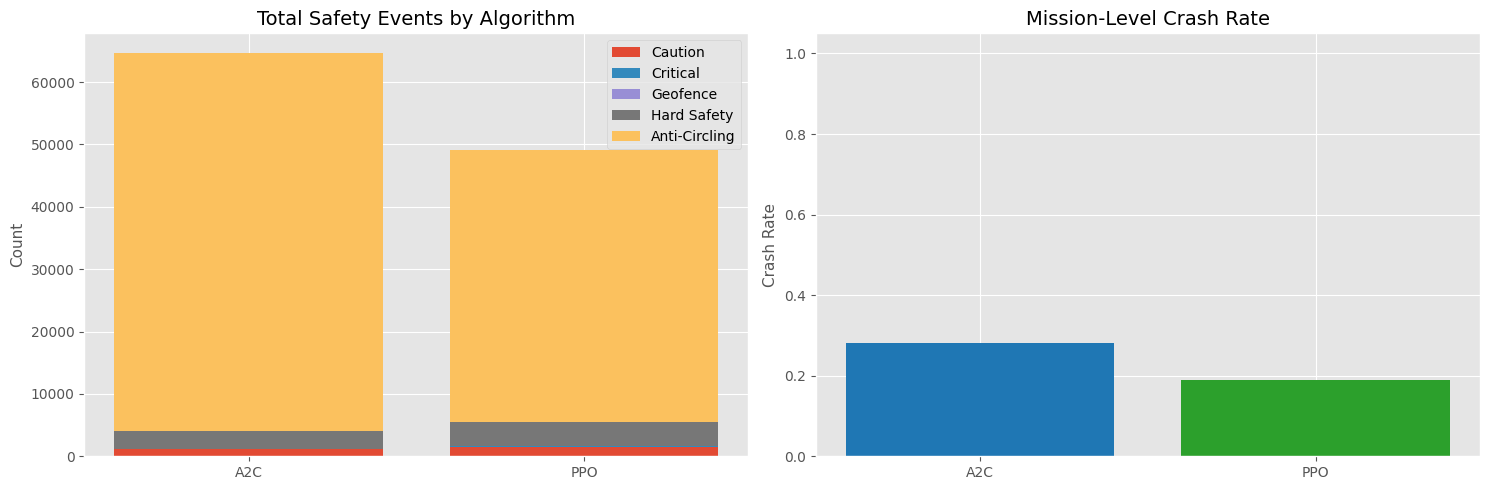

In [26]:
safety_keys = [
    ('caution_count', 'Caution'),
    ('critical_count', 'Critical'),
    ('geofence_count', 'Geofence'),
    ('hard_safety_count', 'Hard Safety'),
    ('anti_circling_count', 'Anti-Circling'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bottom = np.zeros(len(algorithms))
for metric_key, label in safety_keys:
    values = np.array([
        sum(record[metric_key] for record in records if record['algorithm'] == algorithm)
        for algorithm in algorithms
    ])
    axes[0].bar(algorithms, values, bottom=bottom, label=label)
    bottom += values

axes[0].set_title('Total Safety Events by Algorithm')
axes[0].set_ylabel('Count')
axes[0].legend()

crash_rates = [summary[algorithm]['crash_rate'] for algorithm in algorithms]
axes[1].bar(algorithms, crash_rates, color=[colors.get(algorithm, '#444444') for algorithm in algorithms])
axes[1].set_title('Mission-Level Crash Rate')
axes[1].set_ylabel('Crash Rate')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


## Reward Breakdown

The enriched eval output now carries cumulative reward-component totals, which makes it much easier to understand why an algorithm scored well or poorly.

The positive panel shows where reward is being earned. The penalty panel shows how much score is being lost to efficiency, safety, and boundary-related costs.

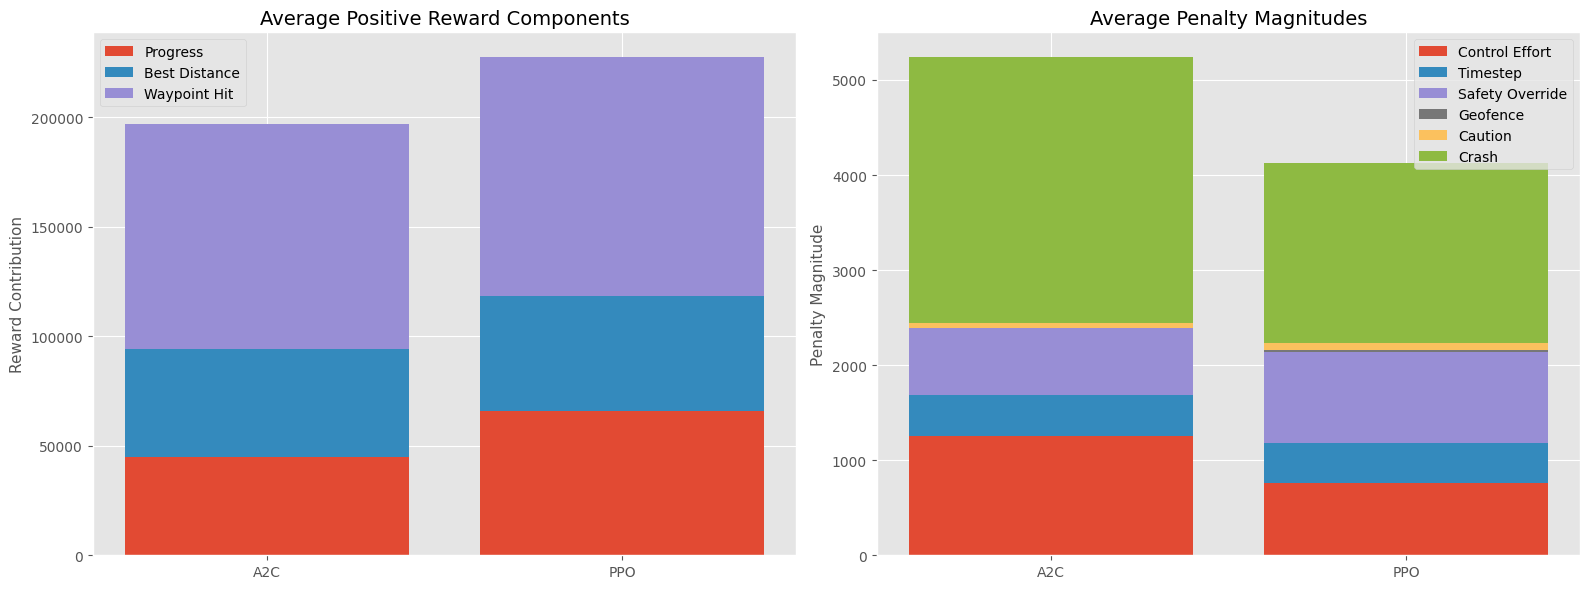

In [27]:
positive_components = [
    ('progress_reward', 'Progress'),
    ('best_dist_bonus', 'Best Distance'),
    ('waypoint_hit_reward', 'Waypoint Hit'),
]
negative_components = [
    ('control_effort_penalty', 'Control Effort'),
    ('timestep_penalty', 'Timestep'),
    ('safety_override_penalty', 'Safety Override'),
    ('geofence_penalty', 'Geofence'),
    ('caution_penalty', 'Caution'),
    ('crash_penalty', 'Crash'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

positive_bottom = np.zeros(len(algorithms))
for component_key, label in positive_components:
    values = np.array([
        mean(record[component_key] for record in records if record['algorithm'] == algorithm)
        for algorithm in algorithms
    ])
    axes[0].bar(algorithms, values, bottom=positive_bottom, label=label)
    positive_bottom += values

negative_bottom = np.zeros(len(algorithms))
for component_key, label in negative_components:
    values = np.abs(np.array([
        mean(record[component_key] for record in records if record['algorithm'] == algorithm)
        for algorithm in algorithms
    ]))
    axes[1].bar(algorithms, values, bottom=negative_bottom, label=label)
    negative_bottom += values

axes[0].set_title('Average Positive Reward Components')
axes[0].set_ylabel('Reward Contribution')
axes[0].legend()

axes[1].set_title('Average Penalty Magnitudes')
axes[1].set_ylabel('Penalty Magnitude')
axes[1].legend()

plt.tight_layout()
plt.show()


## Saliency Versus Reward

The evaluator stores a perturbation-based saliency score. This is not a direct quality metric, but it can still be useful as a behavioral diagnostic.

The scatterplot below helps answer whether stronger policies tend to show larger or smaller observation sensitivity during evaluation.

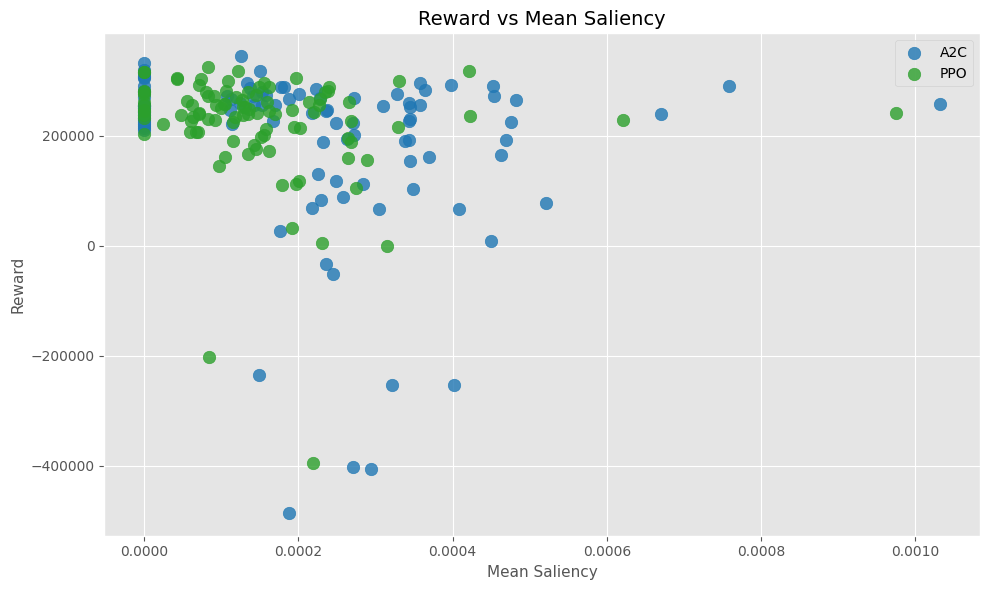

A2C: saliency/reward correlation = -0.1779
PPO: saliency/reward correlation = -0.1328


In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

for algorithm in algorithms:
    algo_records = [record for record in records if record['algorithm'] == algorithm]
    ax.scatter(
        [row['saliency_mean'] for row in algo_records],
        [row['reward'] for row in algo_records],
        s=80,
        alpha=0.8,
        label=algorithm,
        color=colors.get(algorithm, '#444444')
    )

ax.set_title('Reward vs Mean Saliency')
ax.set_xlabel('Mean Saliency')
ax.set_ylabel('Reward')
ax.legend()

plt.tight_layout()
plt.show()

for algorithm in algorithms:
    algo_records = [record for record in records if record['algorithm'] == algorithm]
    rewards = np.array([row['reward'] for row in algo_records], dtype=float)
    saliency = np.array([row['saliency_mean'] for row in algo_records], dtype=float)
    correlation = np.corrcoef(saliency, rewards)[0, 1] if len(algo_records) > 1 and np.std(saliency) > 0 and np.std(rewards) > 0 else float('nan')
    print(f'{algorithm}: saliency/reward correlation = {correlation:.4f}')


## Mission Winners

This last view counts which algorithm wins each mission on raw reward. It is a simple but useful complement to averages because it shows whether a policy dominates broadly or only wins because of a few extreme missions.

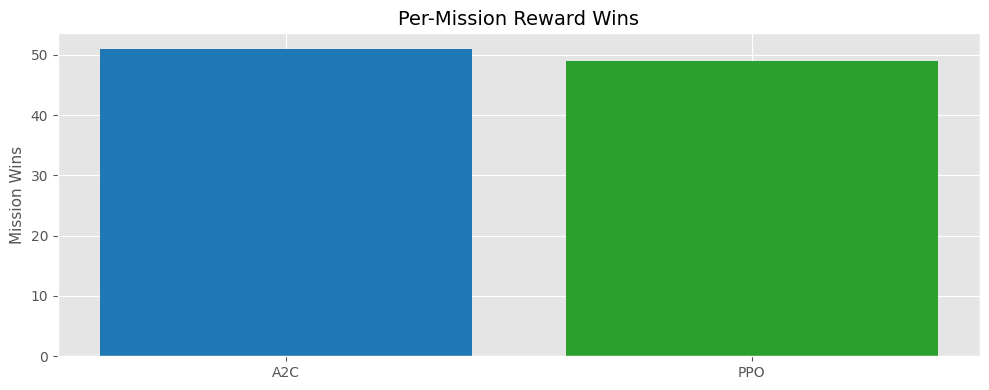

Mission winners:
  Mission 1: PPO
  Mission 2: A2C
  Mission 3: A2C
  Mission 4: PPO
  Mission 5: PPO
  Mission 6: A2C
  Mission 7: PPO
  Mission 8: A2C
  Mission 9: A2C
  Mission 10: A2C
  Mission 11: PPO
  Mission 12: A2C
  Mission 13: A2C
  Mission 14: A2C
  Mission 15: A2C
  Mission 16: A2C
  Mission 17: A2C
  Mission 18: A2C
  Mission 19: A2C
  Mission 20: PPO
  Mission 21: PPO
  Mission 22: A2C
  Mission 23: PPO
  Mission 24: A2C
  Mission 25: PPO
  Mission 26: PPO
  Mission 27: PPO
  Mission 28: PPO
  Mission 29: A2C
  Mission 30: PPO
  Mission 31: PPO
  Mission 32: A2C
  Mission 33: A2C
  Mission 34: A2C
  Mission 35: A2C
  Mission 36: A2C
  Mission 37: PPO
  Mission 38: PPO
  Mission 39: A2C
  Mission 40: A2C
  Mission 41: A2C
  Mission 42: PPO
  Mission 43: PPO
  Mission 44: PPO
  Mission 45: PPO
  Mission 46: PPO
  Mission 47: A2C
  Mission 48: PPO
  Mission 49: A2C
  Mission 50: A2C
  Mission 51: A2C
  Mission 52: PPO
  Mission 53: A2C
  Mission 54: PPO
  Mission 55: A2C
  

In [29]:
mission_winners = []
for mission_index in sorted({record['mission_index'] for record in records}):
    mission_rows = [record for record in records if record['mission_index'] == mission_index]
    winner = max(mission_rows, key=lambda row: row['reward'])['algorithm']
    mission_winners.append((mission_index, winner))

winner_counts = {algorithm: sum(1 for _, winner in mission_winners if winner == algorithm) for algorithm in algorithms}

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(winner_counts.keys(), winner_counts.values(), color=[colors.get(algorithm, '#444444') for algorithm in winner_counts])
ax.set_title('Per-Mission Reward Wins')
ax.set_ylabel('Mission Wins')
plt.tight_layout()
plt.show()

print('Mission winners:')
for mission_index, winner in mission_winners:
    print(f'  Mission {mission_index}: {winner}')
